In [1]:
import keras
import os
import struct
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout, MaxPooling2D, Conv2D, Dense, Flatten, Activation

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, GlobalAveragePooling2D
from sklearn.model_selection import StratifiedKFold
import cv2
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
from sklearn import metrics as mt
from matplotlib import pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Reshape, Input
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import RandomFlip, RandomRotation
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import average 
from tensorflow.keras.models import  Model

2024-11-25 23:15:57.903648: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-11-25 23:16:00.050661: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-11-25 23:16:00.882060: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1732598161.375965 1475532 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1732598161.588790 1475532 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-25 23:16:03.148759: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

In [2]:
def load_dataset(path):
    images = []
    labels = []
    label_classes = os.listdir(path)
    for label in label_classes:
        img_names = os.listdir(os.path.join(path, label))
        for img_name in img_names:
            img_path = os.path.join(path, label, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                print(f"Warning: Could not read image {img_path}. Skipping.")
                continue
            img = cv2.resize(img, (28, 28))
            images.append(img)
            labels.append(label)
    images = np.array(images)
    labels = np.array(labels)
    return images, labels

X, y = load_dataset('Data/Data')

In [3]:
# Normalize the images.
X = X.reshape(X.shape[0], 28, 28, 1) / 255.0 - 0.5

# Use LabelEncoder to encode labels into integers
le = LabelEncoder()
y = le.fit_transform(y)

# Number of classes
NUM_CLASSES = len(np.unique(y))

# One-hot encode the labels
y_ohe = to_categorical(y, NUM_CLASSES)

In [4]:
%matplotlib inline

def compare_mlp_cnn(cnn, mlp, X_test, y_test, labels='auto'):
    plt.figure(figsize=(15,5))
    if cnn is not None:
        yhat_cnn = np.argmax(cnn.predict(X_test), axis=1)
        
        
        y_test_int = np.argmax(y_test, axis=1)  # Convert y_test to integer labels
        acc_cnn = mt.accuracy_score(y_test_int,yhat_cnn)
        
        
        # acc_cnn = mt.accuracy_score(y_test,yhat_cnn)
        plt.subplot(1,2,1)
        # cm = mt.confusion_matrix(y_test,yhat_cnn)
        cm = mt.confusion_matrix(y_test_int,yhat_cnn)
        cm = cm/np.sum(cm,axis=1)[:,np.newaxis]
        sns.heatmap(cm, annot=True, fmt='.2f',xticklabels=labels,yticklabels=labels)
        plt.title(f'CNN: {acc_cnn:.4f}')
    
    if mlp is not None:
        yhat_mlp = np.argmax(mlp.predict(X_test), axis=1)
        
        
        y_test_int = np.argmax(y_test, axis=1)  # Convert y_test to integer labels
        acc_mlp = mt.accuracy_score(y_test_int,yhat_cnn)
        
        
        # acc_mlp = mt.accuracy_score(y_test,yhat_mlp)
        
        plt.subplot(1,2,2)
        cm = mt.confusion_matrix(y_test_int,yhat_mlp)
        # cm = mt.confusion_matrix(y_test,yhat_mlp)
        cm = cm/np.sum(cm,axis=1)[:,np.newaxis]
        sns.heatmap(cm,annot=True, fmt='.2f',xticklabels=labels,yticklabels=labels)
        plt.title(f'MLP: {acc_mlp:.4f}')
labels = [
    "Ace", "Akainu", "Brook", "Chopper", "Crocodile", "Franky", "Jinbei",
    "Kurohige", "Law", "Luffy", "Mihawk", "Nami", "Rayleigh", "Robin",
    "Sanji", "Shanks", "Usopp", "Zoro"
]

In [5]:
# %%time
# Define data augmentation

data_augmentation = Sequential([
        RandomFlip("horizontal"),
        RandomRotation(0.2),
])
# make a keras MLP
def createMLP():
        mlp = Sequential()
        mlp.add(data_augmentation)
        mlp.add( Flatten() )
        mlp.add( Dense(input_dim=1, units=100, activation='relu') )
        mlp.add( Dense(units=50, activation='relu') )
        mlp.add( Dense(units=50, activation='relu') )
        mlp.add( Dense(NUM_CLASSES) )
        mlp.add( Activation('softmax') )

        mlp.compile(loss='categorical_crossentropy',
                optimizer='rmsprop',
                metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

        input_shape = [None, 28,28,1]
        mlp.build(input_shape)
        return mlp

2024-11-25 23:18:18.778232: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [6]:
def createCNN1():
    cnn1 = Sequential()
    cnn1.add(data_augmentation)
    num_filt_layers = [24, 24]
    for num_filters in num_filt_layers:
        cnn1.add( Conv2D(filters=num_filters, 
                        kernel_size=(3,3), 
                        padding='same') )
        cnn1.add( Activation('relu'))
        cnn1.add( MaxPooling2D(pool_size=(2, 2), 
                            ) )
        

    # add one layer on flattened output
    cnn1.add( Flatten() )
    cnn1.add( Dense(100, activation='relu') )
    cnn1.add( Dense(100, activation='relu') )
    cnn1.add( Dense(NUM_CLASSES, activation='softmax') )
    
    cnn1.compile(loss='mean_squared_error',
              optimizer='rmsprop',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])  
    input_shape = [None, 28,28,1]
    cnn1.build(input_shape)  
    return cnn1

def createCNN2():
    cnn2 = Sequential()
    cnn2.add(data_augmentation)
    # let's start with an AlexNet style convolutional phase
    cnn2.add(Conv2D(filters=32,
                    input_shape = (28,28,1),
                    kernel_size=(3,3), 
                    padding='same', 
                    activation='relu')) # more compact syntax

    # no max pool before next conv layer!!
    cnn2.add(Conv2D(filters=64,
                    kernel_size=(3,3), 
                    padding='same', 
                    activation='relu')) # more compact syntax
    cnn2.add(MaxPooling2D(pool_size=(2, 2)))
        

    # add one layer on flattened output
    cnn2.add(Dropout(0.25)) # add some dropout for regularization after conv layers
    cnn2.add(Flatten())
    cnn2.add(Dense(128, activation='relu'))
    cnn2.add(Dropout(0.5)) # add some dropout for regularization, again!
    cnn2.add(Dense(NUM_CLASSES, activation='softmax'))

    # Let's train the model 
    cnn2.compile(loss='categorical_crossentropy', # 'categorical_crossentropy' 'mean_squared_error'
                optimizer='rmsprop', # 'adadelta' 'rmsprop'
                metrics=['accuracy',tf.keras.metrics.AUC(name='auc')])
    input_shape = [None, 28,28,1]
    cnn2.build(input_shape)  
    return cnn2
    
def createCNN3():
    cnn3 = Sequential()
    cnn3.add(data_augmentation)
    num_filt_layers = [32, 32]  # Changed number of filters
    for num_filters in num_filt_layers:
        cnn3.add(Conv2D(filters=num_filters, 
                        kernel_size=(5,5),  # Changed kernel size
                        padding='same'))
        cnn3.add(Activation('relu'))
        cnn3.add(MaxPooling2D(pool_size=(2, 2)))

    # add one layer on flattened output
    cnn3.add(Flatten())
    cnn3.add(Dense(128, activation='relu'))  # Changed number of neurons
    cnn3.add(Dense(128, activation='relu'))  # Changed number of neurons
    cnn3.add(Dense(NUM_CLASSES, activation='softmax'))
    
    cnn3.compile(loss='mean_squared_error',
              optimizer='adam',  # Changed optimizer
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])  
    input_shape = [None, 28,28,1]
    cnn3.build(input_shape)  
    return cnn3

def createCNN4():
    cnn4 = Sequential()
    cnn4.add(data_augmentation)
    cnn4.add(Conv2D(filters=48,  # Changed number of filters
                    input_shape = (28,28,1),
                    kernel_size=(5,5),  # Changed kernel size
                    padding='same', 
                    activation='relu'))

    cnn4.add(Conv2D(filters=96,  # Changed number of filters
                    kernel_size=(5,5),  # Changed kernel size
                    padding='same', 
                    activation='relu'))
    cnn4.add(MaxPooling2D(pool_size=(2, 2)))

    cnn4.add(Dropout(0.3))  # Changed dropout rate
    cnn4.add(Flatten())
    cnn4.add(Dense(256, activation='relu'))  # Changed number of neurons
    cnn4.add(Dropout(0.5)) 
    cnn4.add(Dense(NUM_CLASSES, activation='softmax'))

    cnn4.compile(loss='categorical_crossentropy',
                optimizer='adam',  # Changed optimizer
                metrics=['accuracy',tf.keras.metrics.AUC(name='auc')])
    input_shape = [None, 28,28,1]
    cnn4.build(input_shape)  
    return cnn4

In [7]:
import matplotlib.pyplot as plt

def plot_histories(histories, labels):
    # Create new labels list with labels for both training and validation lines
    # new_labels = [f'{label} Train' for label in labels] + [f'{label} Validation' for label in labels]
    new_labels = [f'{labels[i//2]} {["Train", "Validation"][i%2]}' for i in range(2*len(labels))]
    # Plot training & validation accuracy values
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    for history, label in zip(histories, labels):
        plt.plot(history.history['accuracy'])
        plt.plot(history.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(new_labels, loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    for history, label in zip(histories, labels):
        plt.plot(history.history['loss'])
        plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(new_labels, loc='upper left')
    plt.show()

In [8]:
# %%time
# Define data augmentation

data_augmentation = Sequential([
        RandomFlip("horizontal"),
        RandomRotation(0.2),
])
# make a keras MLP
def createMLP():
        mlp = Sequential()
        mlp.add(data_augmentation)
        mlp.add( Flatten() )
        mlp.add( Dense(input_dim=1, units=100, activation='relu') )
        mlp.add( Dense(units=50, activation='relu') )
        mlp.add( Dense(units=50, activation='relu') )
        mlp.add( Dense(NUM_CLASSES) )
        mlp.add( Activation('softmax') )

        mlp.compile(loss='categorical_crossentropy',
                optimizer='rmsprop',
                metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

        input_shape = [None, 28,28,1]
        mlp.build(input_shape)
        return mlp

        # mlp.fit(X_train, y_train_ohe, 
        #         batch_size=32, epochs=3, 
        #         shuffle=True, verbose=1)

In [9]:
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model


def TransferCNN():
    # Load pre-trained MobileNet model without the top layers
    data_augmentation = Sequential([
        RandomFlip("horizontal"),
        RandomRotation(0.2),
    ])
    
    base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

    # Add a global spatial average pooling layer
    x = base_model.output
    x = GlobalAveragePooling2D()(x)

    # Add a fully-connected layer
    x = Dense(1024, activation='relu')(x)

    # Add a logistic layer with the number of classes
    predictions = Dense(NUM_CLASSES, activation='softmax')(x)

    # Define the model
    model = Model(inputs=base_model.input, outputs=predictions)
    
    model = Sequential([
        data_augmentation,
        model
    ])

    # Freeze the layers of the base model (we won't update the weights during training)
    for layer in base_model.layers:
        layer.trainable = False

    # Compile the model
    model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy',tf.keras.metrics.AUC(name='auc')])
    return model

X_train shape: (5868, 28, 28, 1)
X_test shape: (5869, 28, 28, 1)
y_train shape: (5868, 18)
y_test shape: (5869, 18)
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


/lustre/work/client/users/cdcook/.conda/envs/cobaya_2024/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


/lustre/work/client/users/cdcook/.conda/envs/cobaya_2024/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


/lustre/work/client/users/cdcook/.conda/envs/cobaya_2024/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step
184/184 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step


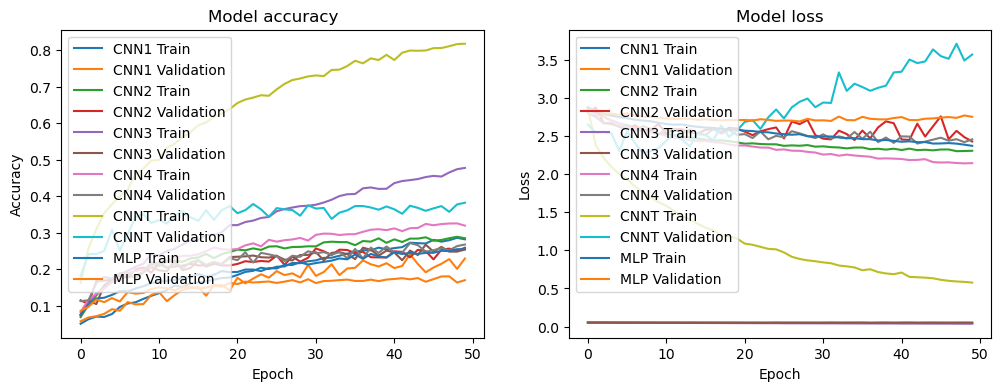

X_train shape: (5869, 28, 28, 1)
X_test shape: (5868, 28, 28, 1)
y_train shape: (5869, 18)
y_test shape: (5868, 18)
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


/lustre/work/client/users/cdcook/.conda/envs/cobaya_2024/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


/lustre/work/client/users/cdcook/.conda/envs/cobaya_2024/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


/lustre/work/client/users/cdcook/.conda/envs/cobaya_2024/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 837us/step
184/184 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step


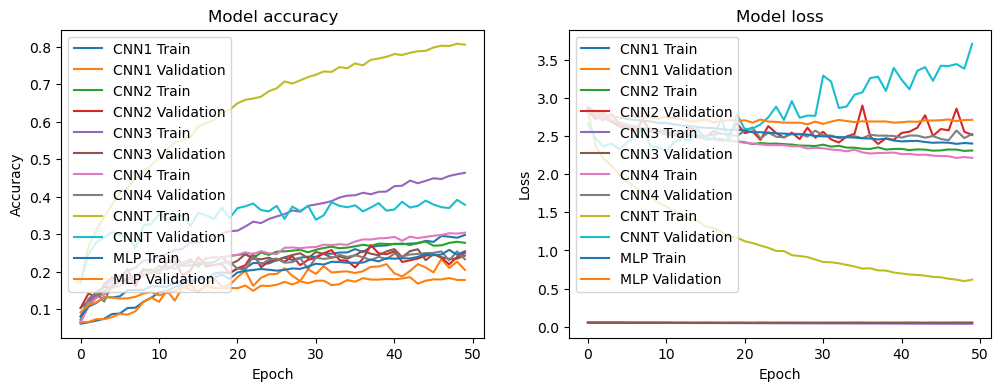

In [10]:
from sklearn.metrics import roc_auc_score

# Stratified 10-fold cross-validation
skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
cnn1_accuracies = []
cnn2_accuracies = []
cnn3_accuracies = []
cnn4_accuracies = []
cnnT_accuracies = []
mlp_accuracies = []
cnn1_auc_scores = []
cnn2_auc_scores = []
cnn3_auc_scores = []
cnn4_auc_scores = []
cnnT_auc_scores = []
mlp_auc_scores = []
#use this for training the thing
es = 50
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y_ohe[train_index], y_ohe[test_index]
    print('X_train shape:', X_train.shape) 
    print('X_test shape:', X_test.shape)

    print('y_train shape:', y_train.shape) 
    print('y_test shape:', y_test.shape)
    # Train and evaluate the first CNN
    cnn1 = createCNN1()
    history1 = cnn1.fit(X_train, y_train, batch_size=32, epochs=es, shuffle=True, verbose=0, validation_data=(X_test,y_test))
    cnn1_accuracies.append(history1.history['val_accuracy'][-1])
    y_pred_probs = cnn1.predict(X_test)  # Predict the probabilities of the positive class
    cnn1_auc_scores.append(roc_auc_score(y_test, y_pred_probs))  # Calculate the AUC score

    # cnn1_auc_scores.append(history1.history['val_auc'][-1])  # Extract AUC from history


    # Train and evaluate the second CNN
    cnn2 = createCNN2()
    history2 = cnn2.fit(X_train, y_train, batch_size=32, epochs=es, shuffle=True, verbose=0, validation_data=(X_test,y_test))
    cnn2_accuracies.append(history2.history['val_accuracy'][-1])
    y_pred_probs = cnn2.predict(X_test)  # Predict the probabilities of the positive class
    cnn2_auc_scores.append(roc_auc_score(y_test, y_pred_probs))  # Calculate the AUC score

    # cnn2_auc_scores.append(history2.history['val_auc'][-1])  # Extract AUC from history
    
    # Train and evaluate the third CNN
    cnn3 = createCNN3()
    history3 = cnn3.fit(X_train, y_train, batch_size=32, epochs=es, shuffle=True, verbose=0, validation_data=(X_test,y_test))
    cnn3_accuracies.append(history3.history['val_accuracy'][-1])
    y_pred_probs = cnn3.predict(X_test)  # Predict the probabilities of the positive class
    cnn3_auc_scores.append(roc_auc_score(y_test, y_pred_probs))  # Calculate the AUC score

    # cnn3_auc_scores.append(history3.history['val_auc'][-1])

    # Train and evaluate the fourth CNN
    cnn4 = createCNN4()
    history4 = cnn4.fit(X_train, y_train, batch_size=32, epochs=es, shuffle=True, verbose=0, validation_data=(X_test,y_test))
    cnn4_accuracies.append(history4.history['val_accuracy'][-1])
    y_pred_probs = cnn4.predict(X_test)  # Predict the probabilities of the positive class
    cnn4_auc_scores.append(roc_auc_score(y_test, y_pred_probs))  # Calculate the AUC score

    # cnn4_auc_scores.append(history4.history['val_auc'][-1])

    # Train and evaluate the MLP
    mlp = createMLP()
    # history_mlp = mlp.fit(X_train, y_train, batch_size=32, epochs=es, shuffle=True, verbose=0)
    history_mlp = mlp.fit(X_train, y_train, batch_size=32, epochs=es, shuffle=True, verbose=0, validation_data=(X_test, y_test))
    mlp_accuracies.append(history_mlp.history['val_accuracy'][-1])
    y_pred_probs = mlp.predict(X_test)  # Predict the probabilities of the positive class
    mlp_auc_scores.append(roc_auc_score(y_test, y_pred_probs))
    # mlp_auc_scores.append(history_mlp.history['val_auc'][-1])  # Extract AUC from history
    
    cnnT = TransferCNN()
    # Resize and convert images to RGB
    X_train_rgb = np.array([cv2.cvtColor(cv2.resize(img.astype('float32'), (128, 128)), cv2.COLOR_GRAY2RGB) for img in X_train])
    X_test_rgb = np.array([cv2.cvtColor(cv2.resize(img.astype('float32'), (128, 128)), cv2.COLOR_GRAY2RGB) for img in X_test])

    # Now, you can use these RGB images to train your model
    historyT = cnnT.fit(X_train_rgb, y_train, epochs=es, verbose=0, validation_data=(X_test_rgb, y_test))
    cnnT_accuracies.append(historyT.history['val_accuracy'][-1])
    y_pred_probs = cnnT.predict(X_test_rgb)  # Predict the probabilities of the positive class
    cnnT_auc_scores.append(roc_auc_score(y_test, y_pred_probs))  # Calculate the AUC score

    # cnnT_auc_scores.append(historyT.history['val_auc'][-1])
        
    # Assuming history1, history2, history3, history4, and history_mlp are the history objects for cnn1, cnn2, cnn3, cnn4, and mlp respectively
    plot_histories([history1, history2, history3, history4, historyT, history_mlp], ['CNN1', 'CNN2', 'CNN3', 'CNN4','CNNT', 'MLP'])
    # plot_histories([history1, history_mlp], ['CNN1', 'MLP'])
    
    
 
    
    # history = cnn1.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))
    
    # score = cnn1.evaluate(X_test, y_test, verbose=0)

Average AUC for CNN1: 0.7377010417426033
Average AUC for CNN2: 0.775782454349994
Average AUC for CNN3: 0.7510901408589066
Average AUC for CNN4: 0.7693869363395419
Average AUC for CNNT: 0.8427057411178247
Average AUC for MLP: 0.6924912878393248
Average accuracy for CNN1: 0.2170902043581009
Average accuracy for CNN2: 0.25449396669864655
Average accuracy for CNN3: 0.24835941940546036
Average accuracy for CNN4: 0.2503180280327797
Average accuracy for CNNT: 0.38025033473968506
Average accuracy for MLP: 0.17398005723953247


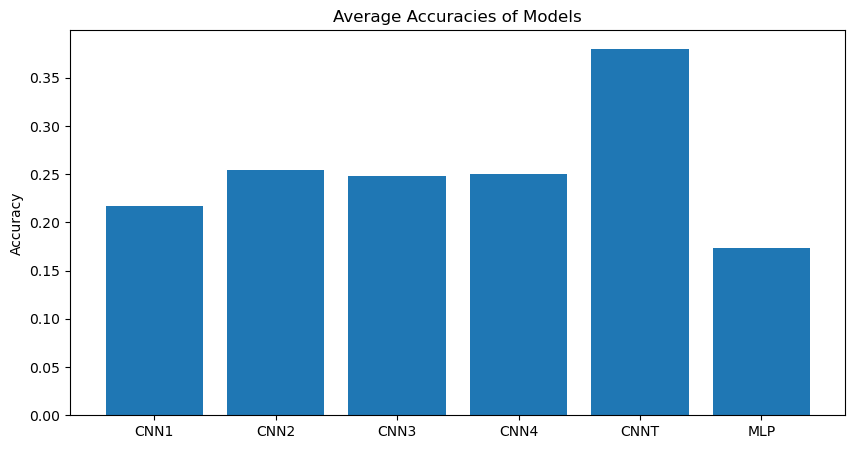

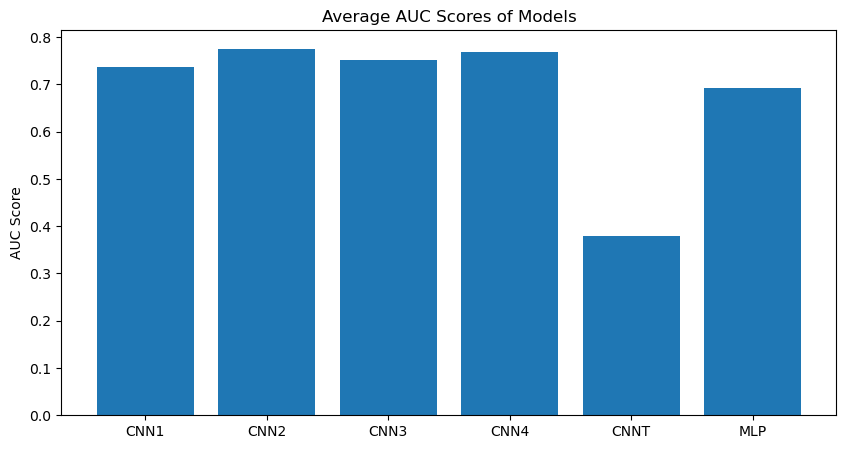

p-value for CNN1 vs CNN2 accuracies: 0.1329493206690605
p-value for CNN1 vs CNN3 accuracies: 0.13502779481379823
p-value for CNN1 vs CNN4 accuracies: 0.0971279310545321
p-value for CNN1 vs CNNT accuracies: 0.04088762488150276
p-value for CNN1 vs MLP accuracies: 0.22863537446474155
p-value for CNN2 vs CNN3 accuracies: 0.12231092213515651
p-value for CNN2 vs CNN4 accuracies: 0.8026419655494503
p-value for CNN2 vs CNNT accuracies: 0.012991871175100667
p-value for CNN2 vs MLP accuracies: 0.06506506269199434
p-value for CNN3 vs CNN4 accuracies: 0.8956571796687507
p-value for CNN3 vs CNNT accuracies: 0.018144401522387894
p-value for CNN3 vs MLP accuracies: 0.08046024859494011
p-value for CNN4 vs CNNT accuracies: 0.07608352583308876
p-value for CNN4 vs MLP accuracies: 0.1731764135144771
p-value for CNNT vs MLP accuracies: 0.0175595015482252


In [11]:
# Compute average AUC and accuracy for each model
avg_auc_cnn1 = np.mean(cnn1_auc_scores)
avg_auc_cnn2 = np.mean(cnn2_auc_scores)
avg_auc_cnn3 = np.mean(cnn3_auc_scores)
avg_auc_cnn4 = np.mean(cnn4_auc_scores)
avg_auc_cnnT = np.mean(cnnT_auc_scores)
avg_auc_mlp = np.mean(mlp_auc_scores)

avg_acc_cnn1 = np.mean(cnn1_accuracies)
avg_acc_cnn2 = np.mean(cnn2_accuracies)
avg_acc_cnn3 = np.mean(cnn3_accuracies)
avg_acc_cnn4 = np.mean(cnn4_accuracies)
avg_acc_cnnT = np.mean(cnnT_accuracies)
avg_acc_mlp = np.mean(mlp_accuracies)

# Print average AUC and accuracy for each model
print('Average AUC for CNN1:', avg_auc_cnn1)
print('Average AUC for CNN2:', avg_auc_cnn2)
print('Average AUC for CNN3:', avg_auc_cnn3)
print('Average AUC for CNN4:', avg_auc_cnn4)
print('Average AUC for CNNT:', avg_auc_cnnT)
print('Average AUC for MLP:', avg_auc_mlp)

print('Average accuracy for CNN1:', avg_acc_cnn1)
print('Average accuracy for CNN2:', avg_acc_cnn2)
print('Average accuracy for CNN3:', avg_acc_cnn3)
print('Average accuracy for CNN4:', avg_acc_cnn4)
print('Average accuracy for CNNT:', avg_acc_cnnT)
print('Average accuracy for MLP:', avg_acc_mlp)

import matplotlib.pyplot as plt

# Average accuracies
plt.figure(figsize=(10, 5))
plt.bar(['CNN1', 'CNN2', 'CNN3', 'CNN4','CNNT', 'MLP'], [avg_acc_cnn1, avg_acc_cnn2, avg_acc_cnn3, avg_acc_cnn4, avg_acc_cnnT, avg_acc_mlp])
plt.title('Average Accuracies of Models')
plt.ylabel('Accuracy')
plt.show()

# Average AUC scores
plt.figure(figsize=(10, 5))
plt.bar(['CNN1', 'CNN2', 'CNN3', 'CNN4','CNNT', 'MLP'], [avg_auc_cnn1, avg_auc_cnn2, avg_auc_cnn3, avg_auc_cnn4, avg_acc_cnnT, avg_auc_mlp])
plt.title('Average AUC Scores of Models')
plt.ylabel('AUC Score')
plt.show()

from scipy import stats

# List of all models' accuracies
accuracies = [cnn1_accuracies, cnn2_accuracies, cnn3_accuracies, cnn4_accuracies,cnnT_accuracies, mlp_accuracies]
labels = ['CNN1', 'CNN2', 'CNN3', 'CNN4','CNNT', 'MLP']

# Compare accuracies of all pairs of models
for i in range(len(accuracies)):
    for j in range(i+1, len(accuracies)):
        t_stat, p_val = stats.ttest_rel(accuracies[i], accuracies[j])
        print(f'p-value for {labels[i]} vs {labels[j]} accuracies: {p_val}')